Euler's Method Visualization and Calculator
Enter a differential equation in terms of x and y

Examples:
  - Linear: x - y
  - Nonlinear: x**2 + y**2
  - Trigonometric: sin(x) * cos(y)
  - Exponential: exp(-x) * y
  - Product: x*y

Available functions:
  sin, cos, tan, exp, log, sqrt, abs
  arcsin, arccos, arctan, sinh, cosh, tanh
  Mathematical operators: +, -, *, /, **

Enter your differential equation dy/dx = -0.0168*(y-325)

Enter initial condition:
Format (x0, y0): 0,70
Initial condition: (0.0, 70.0)

Enter the x value to solve to: 60

Enter step size(s) for Euler's method
You can enter multiple step sizes to compare (separated by commas)
Example: 0.1, 0.5, 1.0
Step size(s): 15, 7.5, 3.75
Using step size(s): [15.0, 7.5, 3.75]

Do you want to see the calculation table? (yes/no): no

Set the plotting window:
Enter x range (format: min, max) or press Enter for auto: 0,70
Enter y range (format: min, max) or press Enter for auto: 0,300


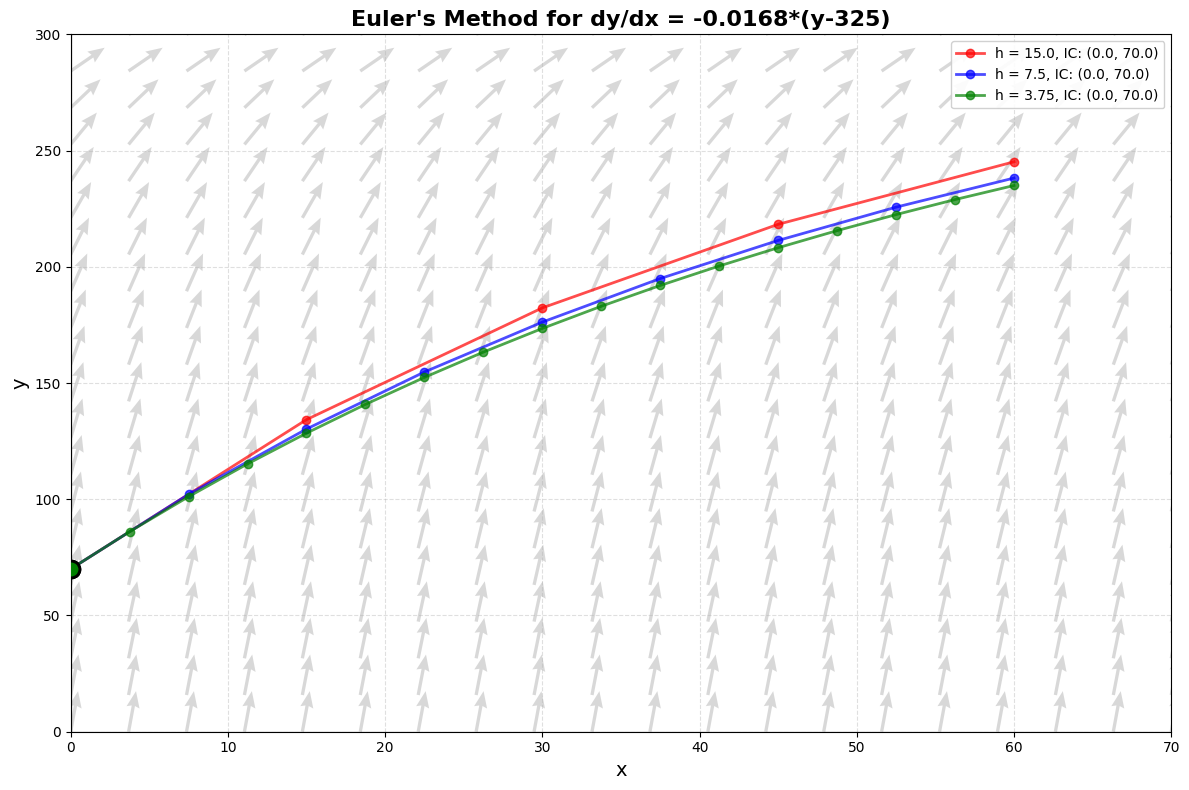

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def evaluate_function(func_str, x, y):
    """Safely evaluate the user's function"""
    try:
        # Create a safe namespace with numpy functions
        namespace = {
            'x': x, 'y': y,
            'sin': np.sin, 'cos': np.cos, 'tan': np.tan,
            'exp': np.exp, 'log': np.log, 'sqrt': np.sqrt,
            'pi': np.pi, 'e': np.e,
            'abs': np.abs, 'arcsin': np.arcsin, 'arccos': np.arccos,
            'arctan': np.arctan, 'sinh': np.sinh, 'cosh': np.cosh,
            'tanh': np.tanh
        }
        result = eval(func_str, {"__builtins__": {}}, namespace)
        return result
    except Exception as e:
        print(f"Error evaluating function: {e}")
        return None

def eulers_method(func_str, x0, y0, x_end, step_size):
    """Apply Euler's method to solve the ODE"""
    try:
        # Calculate number of steps
        n_steps = int(abs(x_end - x0) / step_size)

        # Initialize arrays
        x_values = np.zeros(n_steps + 1)
        y_values = np.zeros(n_steps + 1)

        # Set initial values
        x_values[0] = x0
        y_values[0] = y0

        # Apply Euler's method
        direction = 1 if x_end > x0 else -1
        h = direction * step_size

        for i in range(n_steps):
            x_current = x_values[i]
            y_current = y_values[i]

            # Calculate slope at current point
            slope = evaluate_function(func_str, x_current, y_current)

            if slope is None:
                print("Error: Could not evaluate function")
                return None, None

            # Euler's formula: y_{n+1} = y_n + h * f(x_n, y_n)
            x_values[i + 1] = x_current + h
            y_values[i + 1] = y_current + h * slope

        return x_values, y_values

    except Exception as e:
        print(f"Error in Euler's method: {e}")
        return None, None

def plot_eulers_method(func_str, initial_conditions, step_sizes, x_min, x_max, y_min, y_max):
    """Plot Euler's method approximations with different step sizes"""

    fig, ax = plt.subplots(figsize=(12, 8))

    colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown']

    # Plot each initial condition with different step sizes
    for idx, (x0, y0, x_end) in enumerate(initial_conditions):
        for i, h in enumerate(step_sizes):
            x_euler, y_euler = eulers_method(func_str, x0, y0, x_end, h)

            if x_euler is not None and y_euler is not None:
                color = colors[i % len(colors)]
                label = f"h = {h}, IC: ({x0}, {y0})"

                # Plot the approximation
                ax.plot(x_euler, y_euler, 'o-', color=color, linewidth=2,
                       markersize=6, label=label, alpha=0.7)

                # Mark initial point
                ax.plot(x0, y0, 'o', color=color, markersize=12,
                       markeredgecolor='black', markeredgewidth=2, zorder=5)

    # Add direction field for context
    x_range = np.linspace(x_min, x_max, 20)
    y_range = np.linspace(y_min, y_max, 20)
    X, Y = np.meshgrid(x_range, y_range)

    slopes = evaluate_function(func_str, X, Y)

    if slopes is not None:
        if np.isscalar(slopes):
            slopes = np.full_like(X, slopes)

        dx = np.ones_like(slopes)
        dy = slopes

        magnitude = np.sqrt(dx**2 + dy**2)
        dx = dx / magnitude * 0.3
        dy = dy / magnitude * 0.3

        ax.quiver(X, Y, dx, dy, color='gray', alpha=0.3, scale=8,
                 width=0.003, headwidth=4, headlength=5, zorder=1)

    # Set labels and title
    ax.set_xlabel('x', fontsize=14)
    ax.set_ylabel('y', fontsize=14)
    ax.set_title(f"Euler's Method for dy/dx = {func_str}", fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.4, linestyle='--')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.legend(loc='best', fontsize=10, framealpha=0.9)

    plt.tight_layout()
    plt.show()

def print_euler_table(func_str, x0, y0, x_end, step_size):
    """Print a table showing Euler's method calculations"""
    x_values, y_values = eulers_method(func_str, x0, y0, x_end, step_size)

    if x_values is None or y_values is None:
        print("Could not generate table due to error")
        return

    print("\n" + "=" * 70)
    print(f"Euler's Method Table for dy/dx = {func_str}")
    print(f"Initial condition: y({x0}) = {y0}, Step size h = {step_size}")
    print("=" * 70)
    print(f"{'n':<5} {'x_n':<15} {'y_n':<15} {'f(x_n, y_n)':<15} {'y_{n+1}':<15}")
    print("-" * 70)

    for i in range(len(x_values) - 1):
        x_current = x_values[i]
        y_current = y_values[i]
        slope = evaluate_function(func_str, x_current, y_current)
        y_next = y_values[i + 1]

        print(f"{i:<5} {x_current:<15.6f} {y_current:<15.6f} {slope:<15.6f} {y_next:<15.6f}")

    # Print last point
    print(f"{len(x_values)-1:<5} {x_values[-1]:<15.6f} {y_values[-1]:<15.6f} {'---':<15} {'---':<15}")
    print("=" * 70)

# Main program
print("Euler's Method Visualization and Calculator")
print("=" * 70)
print("Enter a differential equation in terms of x and y")
print("\nExamples:")
print("  - Linear: x - y")
print("  - Nonlinear: x**2 + y**2")
print("  - Trigonometric: sin(x) * cos(y)")
print("  - Exponential: exp(-x) * y")
print("  - Product: x*y")
print("\nAvailable functions:")
print("  sin, cos, tan, exp, log, sqrt, abs")
print("  arcsin, arccos, arctan, sinh, cosh, tanh")
print("  Mathematical operators: +, -, *, /, **")
print("=" * 70)

# Get differential equation
func_input = input("\nEnter your differential equation dy/dx = ")

# Get initial condition
print("\nEnter initial condition:")
while True:
    ic_input = input("Format (x0, y0): ")
    try:
        parts = ic_input.split(',')
        if len(parts) != 2:
            raise ValueError

        namespace = {
            'sin': np.sin, 'cos': np.cos, 'tan': np.tan,
            'exp': np.exp, 'log': np.log, 'sqrt': np.sqrt,
            'pi': np.pi, 'e': np.e, 'abs': abs,
            'arcsin': np.arcsin, 'arccos': np.arccos,
            'arctan': np.arctan, 'sinh': np.sinh,
            'cosh': np.cosh, 'tanh': np.tanh
        }

        x0 = float(eval(parts[0].strip(), {"__builtins__": {}}, namespace))
        y0 = float(eval(parts[1].strip(), {"__builtins__": {}}, namespace))
        print(f"Initial condition: ({x0}, {y0})")
        break
    except:
        print("Invalid format!")
        print("Example: 0, 1  or  -2, 3  or  pi/2, sqrt(2)")
        continue

# Get endpoint
while True:
    try:
        x_end = float(input("\nEnter the x value to solve to: "))
        if x_end == x0:
            print("Error: Endpoint must be different from initial x value")
            continue
        break
    except:
        print("Invalid input! Please enter a number.")
        continue

# Get step size(s)
step_sizes = []
print("\nEnter step size(s) for Euler's method")
print("You can enter multiple step sizes to compare (separated by commas)")
print("Example: 0.1, 0.5, 1.0")

while True:
    step_input = input("Step size(s): ")
    try:
        parts = step_input.split(',')
        for part in parts:
            h = float(part.strip())
            if h <= 0:
                raise ValueError("Step size must be positive")
            step_sizes.append(h)

        if len(step_sizes) == 0:
            raise ValueError("Must enter at least one step size")

        print(f"Using step size(s): {step_sizes}")
        break
    except Exception as e:
        print(f"Invalid input: {e}")
        print("Please enter positive numbers separated by commas")
        step_sizes = []
        continue

# Ask if user wants to see the calculation table
show_table = input("\nDo you want to see the calculation table? (yes/no): ").strip().lower()
if show_table in ['yes', 'y']:
    table_step = step_sizes[0]
    if len(step_sizes) > 1:
        print(f"\nAvailable step sizes: {step_sizes}")
        choice = input(f"Which step size for the table? (press Enter for {step_sizes[0]}): ").strip()
        if choice:
            try:
                table_step = float(choice)
            except:
                print(f"Invalid input, using {step_sizes[0]}")

    print_euler_table(func_input, x0, y0, x_end, table_step)

# Get plot range
print("\nSet the plotting window:")
while True:
    x_range_input = input("Enter x range (format: min, max) or press Enter for auto: ")
    if x_range_input.strip():
        try:
            parts = x_range_input.split(',')
            if len(parts) != 2:
                raise ValueError
            x_min, x_max = map(float, parts)
            if x_min >= x_max:
                print("Error: min must be less than max")
                continue
            break
        except:
            print("Invalid format! Example: -5, 5")
            continue
    else:
        x_min = min(x0, x_end) - 1
        x_max = max(x0, x_end) + 1
        break

while True:
    y_range_input = input("Enter y range (format: min, max) or press Enter for auto: ")
    if y_range_input.strip():
        try:
            parts = y_range_input.split(',')
            if len(parts) != 2:
                raise ValueError
            y_min, y_max = map(float, parts)
            if y_min >= y_max:
                print("Error: min must be less than max")
                continue
            break
        except:
            print("Invalid format! Example: -5, 5")
            continue
    else:
        y_min = y0 - 5
        y_max = y0 + 5
        break

# Plot the results
initial_conditions = [(x0, y0, x_end)]
plot_eulers_method(func_input, initial_conditions, step_sizes, x_min, x_max, y_min, y_max)